In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [4]:
df = pd.read_csv("Avi.csv")
print("Original shape:", df.shape)
df.head()

Original shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Drop rows with missing Cuisines (target) — can't train/evaluate without a label
df = df.dropna(subset=["Cuisines"])

# Fill missing numeric feature values with median
numeric_cols = ["Average Cost for two", "Price range", "Votes", "Longitude", "Latitude"]
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Shape after dropping missing Cuisines:", df.shape)

Shape after dropping missing Cuisines: (9542, 21)


In [4]:
# A restaurant can have multiple cuisines listed, e.g. "North Indian, Chinese".
# We use the FIRST listed cuisine as the primary label.
df["Primary Cuisine"] = df["Cuisines"].apply(lambda x: x.split(",")[0].strip())

# Keep the top N most frequent cuisines; group the rest into "Other"
TOP_N = 15
top_cuisines = df["Primary Cuisine"].value_counts().head(TOP_N).index.tolist()

df["Cuisine Target"] = df["Primary Cuisine"].apply(
    lambda c: c if c in top_cuisines else "Other"
)

df["Cuisine Target"].value_counts()

Cuisine Target
North Indian    2992
Other           1519
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64

In [5]:
feature_cols = [
    "City", "Price range", "Average Cost for two",
    "Has Table booking", "Has Online delivery", "Votes",
    "Aggregate rating"
]

X = df[feature_cols].copy()
y = df["Cuisine Target"]

# Encode categorical columns
label_encoders = {}
categorical_cols = ["City", "Has Table booking", "Has Online delivery"]

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X.head()

,City,Price range,Average Cost for two,Has Table booking,Has Online delivery,Votes,Aggregate rating
0,73,3,1100,1,0,314,4.8
1,73,3,1200,1,0,591,4.5
2,75,4,4000,1,0,270,4.4
3,75,4,1500,0,0,365,4.9
4,75,4,1500,1,0,229,4.8


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 7633, Test size: 1909


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results[name] = {
        "model": model, "y_pred": y_pred,
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1
    }

    print(f"\n===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression =====
Accuracy:  0.3153
Precision: 0.1632
Recall:    0.3153
F1 Score:  0.1788

===== Random Forest =====
Accuracy:  0.3237
Precision: 0.2739
Recall:    0.3237
F1 Score:  0.2894


In [8]:
best_model_name = max(results, key=lambda k: results[k]["f1"])
print(f"### Best model based on weighted F1: {best_model_name} ###\n")

best_pred = results[best_model_name]["y_pred"]

print(classification_report(
    y_test, best_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))

### Best model based on weighted F1: Random Forest ###

              precision    recall  f1-score   support

    American       0.26      0.20      0.22        56
      Bakery       0.17      0.12      0.14       124
        Cafe       0.23      0.18      0.20       123
     Chinese       0.14      0.11      0.12       171
 Continental       0.13      0.09      0.10        47
    Desserts       0.05      0.03      0.04        30
   Fast Food       0.12      0.10      0.11       135
   Ice Cream       0.11      0.08      0.10        36
     Italian       0.15      0.09      0.11        47
      Mithai       0.17      0.10      0.13        49
     Mughlai       0.00      0.00      0.00        43
North Indian       0.43      0.66      0.52       599
       Other       0.39      0.39      0.39       304
       Pizza       0.14      0.09      0.11        46
South Indian       0.00      0.00      0.00        52
 Street Food       0.19      0.15      0.17        47

    accuracy            

In [9]:
report_dict = classification_report(
    y_test, best_pred,
    target_names=target_encoder.classes_,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report_dict).transpose()
per_class_df = per_class_df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
per_class_df = per_class_df.sort_values("f1-score", ascending=False)

per_class_df[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
North Indian,0.427174,0.656093,0.517446,599.0
Other,0.392027,0.388158,0.390083,304.0
American,0.261905,0.196429,0.224490,56.0
Cafe,0.229167,0.178862,0.200913,123.0
Street Food,0.194444,0.148936,0.168675,47.0
Bakery,0.174419,0.120968,0.142857,124.0
Mithai,0.166667,0.102041,0.126582,49.0
Chinese,0.141732,0.105263,0.120805,171.0
Italian,0.153846,0.085106,0.109589,47.0
Fast Food,0.123810,0.096296,0.108333,135.0


In [10]:
worst = per_class_df.tail(3)
best = per_class_df.head(3)

print(f"Best-performing classes: {list(best.index)}")
print(f"Worst-performing classes: {list(worst.index)}")
print(
    "\nLikely causes of weaker performance on some cuisines:\n"
    "- Class imbalance: cuisines with few training samples are harder to learn.\n"
    "- Feature overlap: cuisines sharing similar price range / city distribution\n"
    "  (e.g. Fast Food vs Street Food) are easily confused.\n"
    "- The 'Other' bucket mixes many unrelated cuisines together, so it may show\n"
    "  inflated support but inconsistent precision/recall.\n"
)

Best-performing classes: ['North Indian', 'Other', 'American']
Worst-performing classes: ['Desserts', 'Mughlai', 'South Indian']

Likely causes of weaker performance on some cuisines:
- Class imbalance: cuisines with few training samples are harder to learn.
- Feature overlap: cuisines sharing similar price range / city distribution
  (e.g. Fast Food vs Street Food) are easily confused.
- The 'Other' bucket mixes many unrelated cuisines together, so it may show
  inflated support but inconsistent precision/recall.



In [11]:
rf_model = results["Random Forest"]["model"]
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
5,Votes,0.389140
2,Average Cost for two,0.213080
6,Aggregate rating,0.203153
0,City,0.124469
1,Price range,0.033835
4,Has Online delivery,0.025197
3,Has Table booking,0.011126


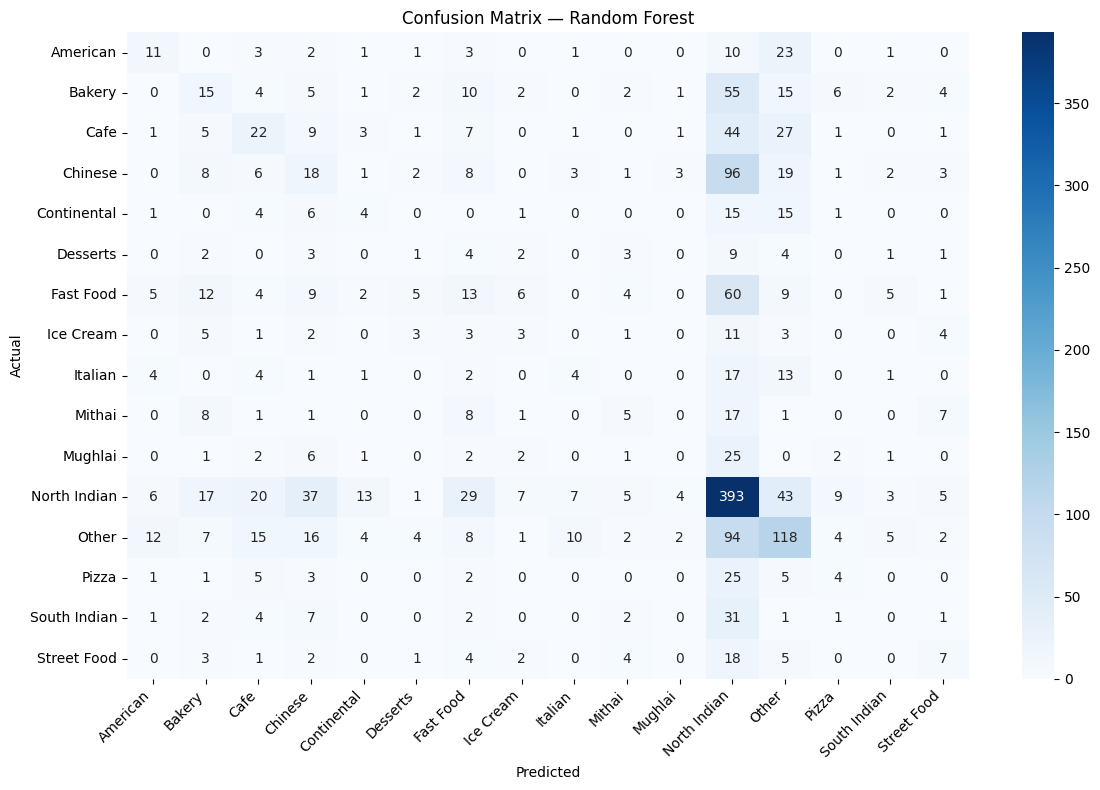

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()